AI Research & Report Generator

In [80]:
from typing import TypedDict, Annotated, List, Literal, Dict, Any
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages


In [81]:
from dotenv import load_dotenv  
load_dotenv()

True

In [82]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.1-8b-instant",
    temperature=0,
    max_tokens=800)

In [83]:
class SupervisorState(TypedDict):
    """State for the multi-agent system"""
    messages: Annotated[list, add_messages] 
    next_agent: str 
    research_data: str 
    analysis_data: str 
    writer_data:str
    review_data: str 
    task_complete: bool 
    current_task: str 

# Create Agents

In [84]:
from langchain_core.prompts import ChatPromptTemplate

In [85]:
def supervisor_prompt():

    supervisor_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a supervisor managing a team of agents:
        
1. Researcher - Gathers information and data
2. Analyst - Analyzes data and provides insights  
3. Writer - Creates reports and summaries
4. Reviewer - Improves the quality of the report

Based on the current state and conversation, decide which agent should work next.
If the task is complete, respond with 'DONE'.

Current state:
- Has research data: {has_research}
- Has analysis: {has_analysis}
- Has report: {has_report}
- Has review: {has_review}

Respond with ONLY the agent name (researcher/analyst/writer/reviewer) or 'DONE'.
"""),
        ("human", "{task}")
    ])

    return supervisor_prompt | llm
    

In [86]:
def supervisor(state: SupervisorState):

     # Check what's been completed
    has_research = bool(state.get("research_data", ""))
    has_analysis = bool(state.get("analysis_data", ""))
    has_report = bool(state.get("writer_data", ""))
    has_review = bool(state.get("review_data", ""))

    chain = supervisor_prompt()
    
    # Get current task
    messages = state.get("messages", [])
    task = task = messages[-1].content if messages else state.get("current_task", "")

    decision = chain.invoke({
        "task": task,
        "has_research": has_research,
        "has_analysis": has_analysis,
        "has_report": has_report,
        "has_review": has_review
    })
     # Parse decision
    dec= decision.content.strip().lower()

    # mapping
    if "done" in dec or has_review:
        next_agent = "end"
        supervisor_msg = "Supervisor: All tasks complete! Great work team."
    elif "researcher" in dec or not has_research:
        next_agent = "researcher"
        supervisor_msg = "Supervisor: Let's start with research. Assigning to Researcher"
    elif "analyst" in dec or (has_research and not has_analysis):
        next_agent = "analyst"
        supervisor_msg = "Supervisor: Research done. Time for analysis. Assigning to Analyst..."
    elif "writer" in dec or (has_analysis and not has_report):
        next_agent = "writer"
        supervisor_msg = "Supervisor: Analysis complete. Let's create the report. Assigning to Writer..."
    elif "reviewer" in dec or (has_report and not has_review):
        next_agent = "reviewer"
        supervisor_msg = "Supervisor: Report created. Time for review. Assigning to Reviewer..."
    else:
        next_agent = "end"
        supervisor_msg = "Supervisor: Task seems complete."

    return {
        "messages": [AIMessage(content=supervisor_msg)],
        "next_agent": next_agent,
        "current_task": task
    }




In [87]:
def researcher_agent(state: SupervisorState) :

    
    task = state.get("current_task", "research topic")
    
    # Create research prompt
    research_prompt = f"""As a research specialist, provide comprehensive information about: {task}

    Include:
    1. Key facts and background
    2. Current trends or developments
    3. Important statistics or data points
    4. Notable examples or case studies
    
    Be concise but thorough."""
    
    # Get research from LLM
    research_response = llm.invoke([HumanMessage(content=research_prompt)])
    research_data = research_response.content
    
    # Create agent message
    agent_message = f"🔍 Researcher: I've completed the research on '{task}'.\n\nKey findings:\n{research_data[:300]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "research_data": research_data,
        "next_agent": "supervisor"
    }

In [88]:
def analyst_agent(state: SupervisorState) :
    """Analyst uses Groq to analyze the research"""
    
    research_data = state.get("research_data", "")
    task = state.get("current_task", "")
    
    # Create analysis prompt
    analysis_prompt = f"""As a data analyst, analyze this research data and provide insights:

Research Data:
{research_data}

Provide:
1. Key insights and patterns
2. Strategic implications
3. Risks and opportunities
4. Recommendations

Focus on actionable insights related to: {task}"""
    
    # Get analysis from LLM
    analysis_response = llm.invoke([HumanMessage(content=analysis_prompt)])
    analysis = analysis_response.content
    
    # Create agent message
    agent_message = f"Analyst: I've completed the analysis.\n\nTop insights:\n{analysis[:200]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "analysis": analysis,
        "next_agent": "supervisor"
    }

In [89]:
def writer_agent(state: SupervisorState) :
    task = state.get("current_task", "")
    research = state.get("research_data", "")
    analysis = state.get("analysis_data", "")

    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a professional report writer.

Create a structured report with:

- Title
- Introduction
- Key Findings
- Analysis
- Conclusion

Use clear, professional language.
"""),
        ("human", """
Topic:
{task}

Research:
{research}

Analysis:
{analysis}

Write a complete report.
""")
    ])

    chain = prompt | llm

    result = chain.invoke({
        "task": task,
        "research": research,
        "analysis": analysis
    })

    writer_data = result.content

    return {
        "writer_data": writer_data,
        "messages": [
            AIMessage(content=f"✍️ Writer: Report draft created.\n\n{writer_data[:200]}")
        ],
        "next_agent": "supervisor"
    }


In [90]:
def reviewer_agent(state: SupervisorState):

    report = state.get("writer_data", "")

    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a senior editor and reviewer.

Improve the report by:

- Fixing clarity
- Improving structure
- Correcting grammar
- Making it professional
- Ensuring completeness

Return the final improved report.
"""),
        ("human", "Report to review:\n{report}")
    ])

    chain = prompt | llm

    result = chain.invoke({
        "report": report
    })

    review_data = result.content

    return {
        "review_data": review_data,
        "messages": [
            AIMessage(content=f"🔍 Reviewer: Final report completed.\n\n{review_data}")
        ],
        "next_agent": "supervisor"
    }

In [91]:
def router(state: SupervisorState) -> Literal["supervisor", "researcher", "analyst", "writer", "reviewer", "__end__"]:
    next_agent = state.get("next_agent", "supervisor")
    task_complete = state.get("task_complete", False)

    # If workflow complete → END
    if task_complete or next_agent in ["end", "__end__", END]:
        return END

    # Valid agent nodes
    valid_nodes = {
        "supervisor",
        "researcher",
        "analyst",
        "writer",
        "reviewer",
    }

    if next_agent in valid_nodes:
        return next_agent

    # Fallback 
    return "supervisor"

Graph WorkFlow

In [92]:
graph = StateGraph(SupervisorState)

In [93]:
graph.add_node("supervisor",supervisor)
graph.add_node("researcher", researcher_agent)
graph.add_node("analyst", analyst_agent)
graph.add_node("writer", writer_agent)
graph.add_node("reviewer", reviewer_agent)

In [94]:
graph.set_entry_point("supervisor")

In [95]:
for node in graph.nodes:
    graph.add_conditional_edges(
        node,
        router,
        {
            "supervisor": "supervisor",
            "researcher": "researcher",
            "analyst": "analyst",
            "writer": "writer",
            "reviewer": "reviewer",
            END: END
        }
    )


In [96]:
app=graph.compile()

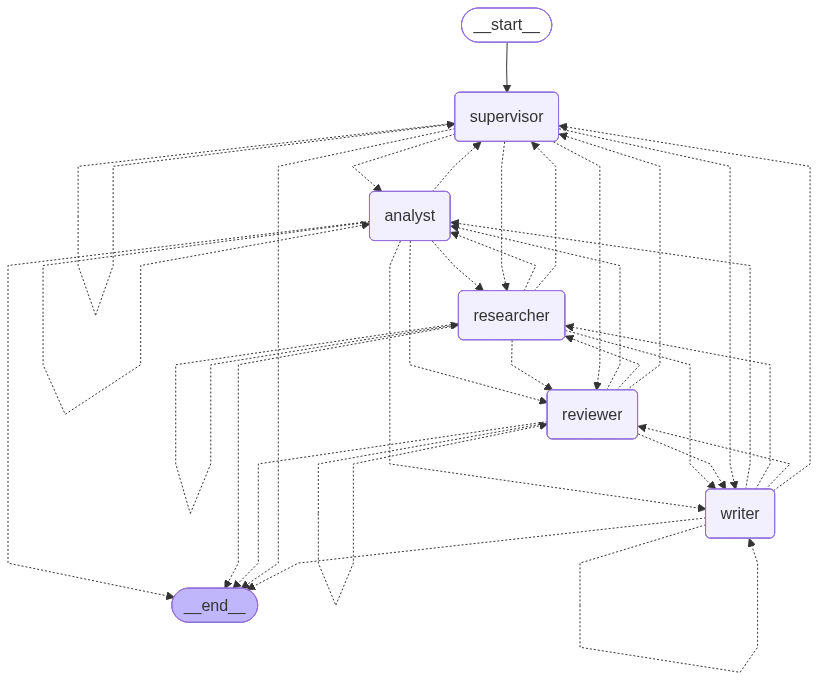

In [97]:
app

Inference

In [99]:
response=app.invoke(HumanMessage(content="What are the benefits and risks of AI in healthcare?"))

response["review_data"]

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.1-8b-instant` in organization `org_01kbjq0b6tfy3s0dnwngagmw64` service tier `on_demand` on tokens per day (TPD): Limit 500000, Used 500000, Requested 669. Please try again in 1m55.6032s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}